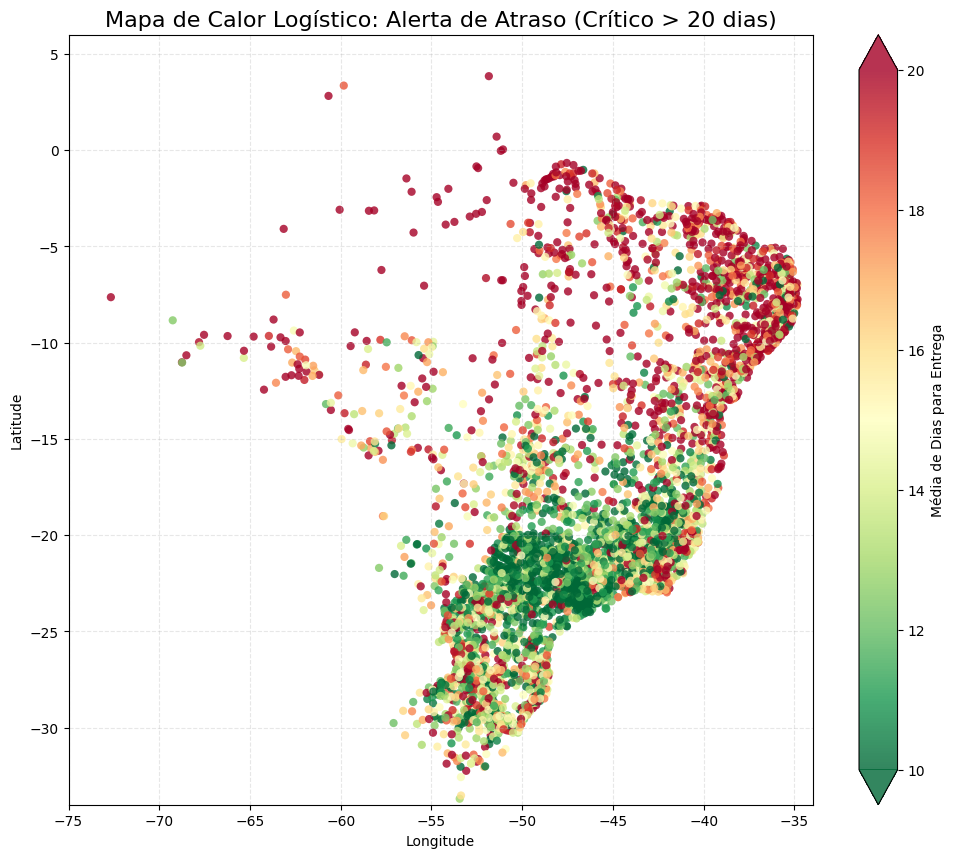

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('/content/Base tratada.xlsx', sheet_name='Base tratada', header=0)

#Para converter os dados de latitude, longituude e Dias para entrega em número
df['Latitude Cliente'] = pd.to_numeric(df['Latitude Cliente'], errors='coerce')
df['Longitude Cliente'] = pd.to_numeric(df['Longitude Cliente'], errors='coerce')
df['Dias para entrega'] = pd.to_numeric(df['Dias para entrega'], errors='coerce')

#Mesmo tratado no Excel, para garantir que essas colunas tenham valor válido
df = df.dropna(subset=['Latitude Cliente', 'Longitude Cliente', 'Dias para entrega'])

#Média por cidade
df_grouped = df.groupby(['Cidade do Cliente', 'Latitude Cliente', 'Longitude Cliente'])['Dias para entrega'].mean().reset_index()

#Tamanho do gráfico para ficar mais visível
plt.figure(figsize=(12, 10))

#Configurando a escala de cores do verde ao vermelho
scatter = plt.scatter(df_grouped['Longitude Cliente'],
                      df_grouped['Latitude Cliente'],
                      c=df_grouped['Dias para entrega'],
                      cmap='RdYlGn_r',
                      vmin=10,
                      vmax=20,
                      s=35,
                      alpha=0.8,
                      edgecolors='none')

#Ajustando as legendas para ficarem mais visíveis
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Média de Dias para Entrega')

plt.title('Mapa de Calor Logístico: Alerta de Atraso (Crítico > 20 dias)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)

#Mesmo tratado no Excel, ajustando limites de longitude e latitude o mapa brasileiro para evitar possíveis erros
plt.xlim(-75, -34)
plt.ylim(-34, 6)

plt.show()
